# Baseline CNN

This notebook implements a baseline Convolutional Neural Network (CNN) for brain tumor MRI classification.
The goal of this baseline is to establish a reference performance before experimenting with more advanced architectures such as ResNet and MobileNet.

The pipeline includes:

- Loading preprocessed data
- Building PyTorch Dataset and DataLoader
- Defining a simple CNN model
- Training and validation loop
- Saving the best performing model
- Preparing outputs for later evaluation and comparison

## 1) Import Libraries
In this step, we import all required libraries and prepare the environment for building the deep learning pipeline.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random 
import sys
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

sys.path.append(
    os.path.abspath("..")
)
from src.dataset import BrainTumorDataset
from src.transforms import train_transform, test_transform
from src.trainer import train_model

## 2) Load Processed Dataset

In this step, we load the processed training and validation datasets generated during preprocessing.

The saved files already contain:
- Transformed images
- Labels
- Train / validation split

In [31]:
train_data = torch.load("../data/processed/train_split.pt")
val_data = torch.load("../data/processed/val_split.pt")

train_images, train_labels = train_data
val_images, val_labels = val_data

print("Dataset loaded successfully.")
print("Training Images:", len(train_images))
print("Training Labels:", len(train_labels))
print("Validation Images:", len(val_images))
print("Validation Labels:", len(val_labels))
print("Sample Label:", train_labels[0])

Dataset loaded successfully.
Training Images: 4000
Training Labels: 4000
Validation Images: 1000
Validation Labels: 1000
Sample Label: 1


/tmp/ipykernel_165838/2822197500.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load("../data/processed/train_split.pt")
/tmp/ipykernel_165838/282219

## 3) Create Dataset Objects

In this step, we convert the image paths and labels into PyTorch Dataset objects.

This allows us to:
- Load images dynamically during training
- Apply transformations on-the-fly
- Prepare data for batching using DataLoader

This is a required step before building the training pipeline.

In [32]:
train_dataset = BrainTumorDataset(
    train_images,
    train_labels,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_images,
    val_labels,
    transform=test_transform
)

## 4) DataLoaders

DataLoaders are used to:
- Split data into batches
- Shuffle training data
- Efficiently feed data to the model during training

In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [34]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## 5) Baseline CNN Model

We define a simple Convolutional Neural Network to serve as a baseline model for brain tumor classification.

This model will be used as a reference for future improvements using transfer learning.

In [35]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 4)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

## 6) Training Setup

We define:
- Device (GPU/CPU)
- Loss function
- Optimizer

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 7) Training 

In this step, we train the CNN model using the training data.

Each epoch includes:
- Forward pass
- Loss computation
- Backpropagation
- Parameter update using optimizer

We also evaluate the model on validation data after each epoch.

In [37]:
BASE_DIR = os.path.abspath("..")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "baseline_cnn.pth")

In [38]:
best_acc, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=5,
    device=device,
    model_path=model_path
)

print(f"Best Validation Accuracy: {best_acc:.4f}")

Model updated | Best Val Acc: 0.7570
Epoch [1/5]
Train Loss: 1.3772 | Train Acc: 0.5707
Val Loss: 0.6543 | Val Acc: 0.7570
--------------------------------------------------
Model updated | Best Val Acc: 0.7910
Epoch [2/5]
Train Loss: 0.7359 | Train Acc: 0.6897
Val Loss: 0.5314 | Val Acc: 0.7910
--------------------------------------------------
Model updated | Best Val Acc: 0.8080
Epoch [3/5]
Train Loss: 0.6889 | Train Acc: 0.7255
Val Loss: 0.4961 | Val Acc: 0.8080
--------------------------------------------------
Model updated | Best Val Acc: 0.8160
Epoch [4/5]
Train Loss: 0.6022 | Train Acc: 0.7602
Val Loss: 0.4823 | Val Acc: 0.8160
--------------------------------------------------
Model updated | Best Val Acc: 0.8220
Epoch [5/5]
Train Loss: 0.6026 | Train Acc: 0.7705
Val Loss: 0.4700 | Val Acc: 0.8220
--------------------------------------------------
Best Validation Accuracy: 0.8220


## 8) Plot Baseline CNN Curves

In this step, we visualize the training and validation loss and accuracy of the baseline CNN model.

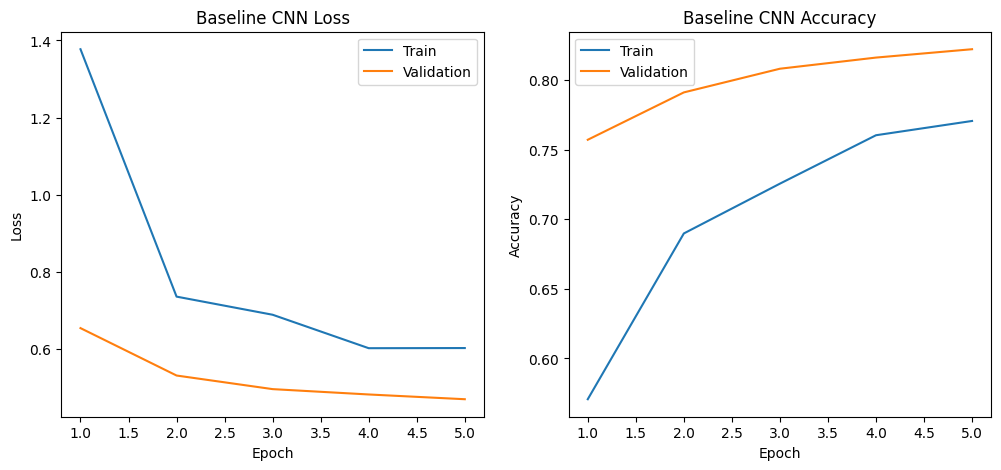

In [39]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], label="Validation")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train")
plt.plot(epochs_range, history["val_acc"], label="Validation")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Summary
In this notebook, we implemented a baseline CNN model for brain tumor MRI classification. The model was trained on the preprocessed dataset containing four classes, using a simple convolutional architecture with batch normalization, max pooling, and dropout for regularization.

The model was trained for 5 epochs, and performance was evaluated on both training and validation sets after each epoch. The training process showed consistent learning behavior, where both training and validation accuracy improved over time.

### Interpretation of Results

These results are good for a baseline model

The model is not final or optimal, it is only a starting point.
There is still room for improvement using:
- Pretrained models (ResNet, MobileNet)
- Data augmentation improvements
- Longer training
- Learning rate tuning
### Conclusion
Overall, the baseline CNN achieved a solid performance of 82.20% validation accuracy, which confirms that the dataset is learnable and the pipeline is correctly built. This baseline will now serve as a reference point for comparing more advanced deep learning models in the next stages of the project.